# HAT Clustering Analysis — Emotional vs Neutral

Each data point is one isolated inference trial. The server is reset, caches are dropped,
and a 2-second stabilisation baseline is observed before every trial.

**Data layout per trial** (`runs/<label>/p<NNNN>/`):
```
perf_stat.csv        — 1ms buckets, 24 perf events (HAT Layer 1 tracepoints + Layer 2 PMU/power)
hat_interrupts.csv   — 100ms: /proc/interrupts, /proc/softirqs, CPU freq per core
proc_sample.csv      — 100ms: system + per-process CPU jiffies, RSS
collector_meta.json  — t0_ns, duration, perf_events list
trial_meta.json      — prompt_index, label, ok, elapsed_ms
```

**Analysis pipeline:**
1. Load pre-extracted feature CSVs (one row per trial, one column per indicator×metric)
2. Confounder check: verify `elapsed_ms` is balanced between conditions
3. Feature selection: exclude artefact indicators and optionally length-confounded metrics
4. Univariate screening: Mann-Whitney U + Bonferroni correction per feature
5. Per-feature k=2 clustering (k-means + GMM) → composite ranking
6. Multi-feature GMM K-sweep on top-K features
7. PCA visualisation of cluster structure
8. Per-indicator × per-metric grid: finest-grained view of which (indicator, metric) pair drives separation
9. Test set evaluation with elapsed_ms residualisation


## 1 — Imports

In [1]:
import json, re, warnings
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

print('Imports OK')


Imports OK


## 2 — Configuration

In [2]:
BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'

print(f'BASE_DIR = {BASE_DIR}')
assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'


BASE_DIR = /Users/rsalvi/Desktop/mccviahat


## 3 — Load features

In [ ]:
_node = 'clemsonc6420'
_data_dir = BASE_DIR / 'data' / _node
RUNS = ['A', 'B', 'D', 'E', 'F']

# ── Load token metadata once (optional) ──────────────────────────────────────
_token_csv = BASE_DIR / 'prompts' / '20base' / 'combined_token_counts.csv'
if _token_csv.exists():
    _tok_df = pd.read_csv(_token_csv)[['condition', 'prompt_index', 'n_tokens', 'title']]
else:
    _tok_df = None

# ── Load each run as its own DataFrame ───────────────────────────────────────
dfs_by_run = {}
loaded_files = []
for run in RUNS:
    csv_path = _data_dir / f'independent{run}.csv'
    assert csv_path.exists(), (
        f'{csv_path.name} not found at {csv_path}\n'
        'Run: python scripts/run/extract_features.py'
    )

    run_df = pd.read_csv(csv_path)
    run_df['run'] = run

    if _tok_df is not None:
        run_df = run_df.merge(_tok_df, on=['condition', 'prompt_index'], how='left')
    else:
        run_df['n_tokens'] = np.nan

    dfs_by_run[run] = run_df
    loaded_files.append(csv_path)

# Combined view (kept for backward compatibility with existing cells)
df_all = pd.concat([dfs_by_run[r] for r in RUNS], ignore_index=True)

# ── Results directory ────────────────────────────────────────────────
RESULTS_DIR = BASE_DIR / 'results' / 'independentABDEF'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results → {RESULTS_DIR}')

if _tok_df is not None:
    _missing = df_all['n_tokens'].isna().sum()
    print(f'  Joined n_tokens from {_token_csv.name}  '
          f'(matched {len(df_all) - _missing}/{len(df_all)} trials'
          + (f', {_missing} unmatched' if _missing else '') + ')')
else:
    print(f'  ⚠  Token counts not found at {_token_csv}')

print('Loaded files:')
for path in loaded_files:
    print(f'  - {path.name}')

print(f'Loaded {len(loaded_files)} runs, {len(df_all)} trials total')
print(f'  neutral: {(df_all.condition == "neutral").sum()}  |  emotional: {(df_all.condition == "emotional").sum()}')
print(f'  Run counts: {df_all["run"].value_counts().sort_index().to_dict()}')
print(f'  Feature columns: {len([c for c in df_all.columns if "__" in c])}')
print(f'Per-run DataFrames available: {list(dfs_by_run.keys())}')


Results → /Users/rsalvi/Desktop/mccviahat/results/independentA
  ⚠  Token counts not found at /Users/rsalvi/Desktop/mccviahat/prompts/20base/combined_token_counts.csv
Loaded: /Users/rsalvi/Desktop/mccviahat/data/clemsonc6420/independentA.csv
  40 trials total  |  neutral: 20  |  emotional: 20
  Feature columns: 550


## 4 — Confounder check: elapsed_ms and n_tokens

If `elapsed_ms` or `n_tokens` (prompt token count) differs significantly between
conditions, any metric that scales with duration or input length is a confounder
rather than a true substrate signal. We check both and set the `LENGTH_CONFOUNDED`
flag used downstream.


In [4]:
from scipy import stats as sp_stats

# ── elapsed_ms ────────────────────────────────────────────────────────────────
# Ensure numeric (the CSV may store elapsed_ms as strings)
df_all['elapsed_ms'] = pd.to_numeric(df_all['elapsed_ms'], errors='coerce')

dur_n = df_all.loc[df_all.condition == 'neutral',   'elapsed_ms'].dropna().values
dur_e = df_all.loc[df_all.condition == 'emotional', 'elapsed_ms'].dropna().values

stat, p_len = sp_stats.mannwhitneyu(dur_n, dur_e, alternative='two-sided')

print(f'Neutral   elapsed_ms:  mean={dur_n.mean():.0f} ms, median={np.median(dur_n):.0f} ms, n={len(dur_n)}')
print(f'Emotional elapsed_ms:  mean={dur_e.mean():.0f} ms, median={np.median(dur_e):.0f} ms, n={len(dur_e)}')
print(f'Mann-Whitney U={stat:.0f},  p={p_len:.4g}')
if p_len < 0.05:
    print('⚠  elapsed_ms differs significantly between conditions (p < 0.05).')
    print('   Metrics that scale with duration may be confounded by prompt length.')
else:
    print('✓  No significant difference in elapsed_ms between conditions.')

# ── n_tokens ──────────────────────────────────────────────────────────────────
print()
if df_all['n_tokens'].notna().any():
    tok_n = df_all.loc[df_all.condition == 'neutral',   'n_tokens'].dropna().values
    tok_e = df_all.loc[df_all.condition == 'emotional', 'n_tokens'].dropna().values
    stat_t, p_tok = sp_stats.mannwhitneyu(tok_n, tok_e, alternative='two-sided')
    print(f'Neutral   n_tokens:    mean={tok_n.mean():.0f},  median={np.median(tok_n):.0f},  n={len(tok_n)}')
    print(f'Emotional n_tokens:    mean={tok_e.mean():.0f},  median={np.median(tok_e):.0f},  n={len(tok_e)}')
    print(f'Mann-Whitney U={stat_t:.0f},  p={p_tok:.4g}')
    if p_tok < 0.05:
        print('⚠  n_tokens differs significantly between conditions (p < 0.05).')
        print('   Metrics that scale with input length may also be confounded.')
    else:
        print('✓  No significant difference in n_tokens between conditions.')
else:
    p_tok = np.nan
    print('n_tokens: not available — run:')
    print('  python scripts/run/token_count_csv.py \\')
    print('    prompts/20base/independentE.json prompts/20base/independentN.json')

LENGTH_CONFOUNDED = p_len < 0.05
print(f'\nLength confound flag (elapsed_ms): LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')

# Shared bin edges for the elapsed_ms histogram below
all_dur = np.concatenate([dur_n, dur_e])
bins = np.linspace(all_dur.min(), all_dur.max(), 30)

Neutral   elapsed_ms:  mean=22550 ms, median=22536 ms, n=20
Emotional elapsed_ms:  mean=22920 ms, median=22832 ms, n=20
Mann-Whitney U=137,  p=0.09091
✓  No significant difference in elapsed_ms between conditions.

n_tokens: not available — run:
  python scripts/run/token_count_csv.py \
    prompts/20base/independentE.json prompts/20base/independentN.json

Length confound flag (elapsed_ms): LENGTH_CONFOUNDED = False


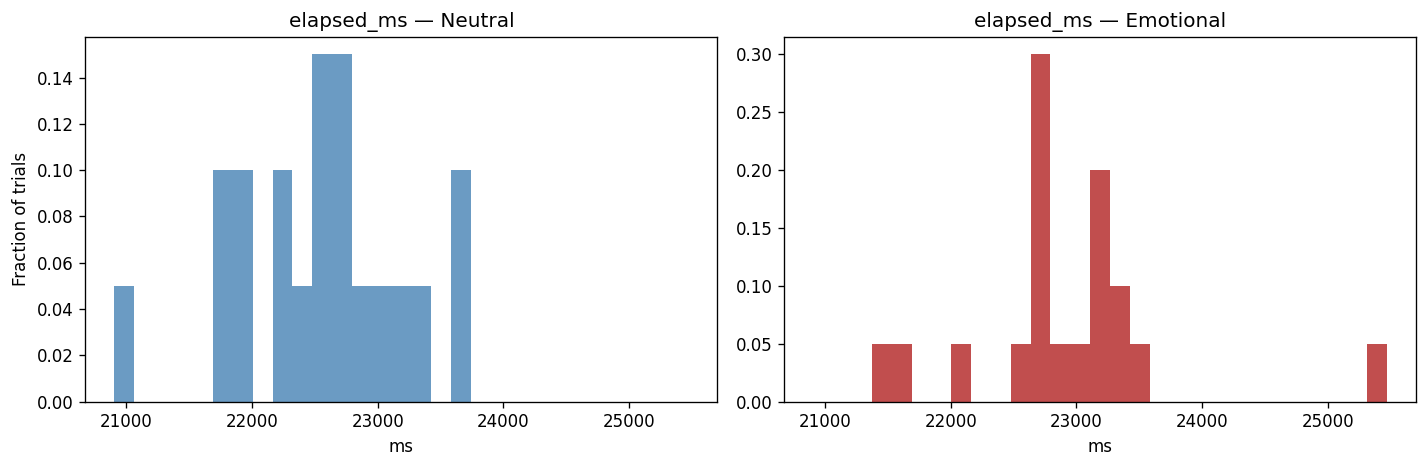


Length confound flag: LENGTH_CONFOUNDED = False
Note: mean_rate is normalised by dur_s — NOT confounded by length.
Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.


In [5]:
weights_n = np.ones(len(dur_n)) / len(dur_n)
weights_e = np.ones(len(dur_e)) / len(dur_e)

has_tokens = df_all['n_tokens'].notna().any()
n_panels = 4 if has_tokens else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4))

axes[0].hist(dur_n, bins=bins, weights=weights_n, color='steelblue', alpha=0.8, label='neutral')
axes[0].set_title('elapsed_ms — Neutral')
axes[0].set_xlabel('ms'); axes[0].set_ylabel('Fraction of trials')

axes[1].hist(dur_e, bins=bins, weights=weights_e, color='firebrick', alpha=0.8, label='emotional')
axes[1].set_title('elapsed_ms — Emotional')
axes[1].set_xlabel('ms')

if has_tokens:
    tok_bins = np.linspace(df_all['n_tokens'].min(), df_all['n_tokens'].max(), 20)
    w_tn = np.ones(len(tok_n)) / len(tok_n)
    w_te = np.ones(len(tok_e)) / len(tok_e)
    axes[2].hist(tok_n, bins=tok_bins, weights=w_tn, color='steelblue', alpha=0.8)
    axes[2].set_title('n_tokens — Neutral')
    axes[2].set_xlabel('tokens'); axes[2].set_ylabel('Fraction of trials')
    axes[3].hist(tok_e, bins=tok_bins, weights=w_te, color='firebrick', alpha=0.8)
    axes[3].set_title('n_tokens — Emotional')
    axes[3].set_xlabel('tokens')

plt.tight_layout()
plt.show()

print(f'\nLength confound flag: LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')
print('Note: mean_rate is normalised by dur_s — NOT confounded by length.')
print('Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.')
if has_tokens:
    print(f'n_tokens confounder: p={p_tok:.4g}  '
          + ('⚠ significant' if p_tok < 0.05 else '✓ not significant'))


## 5 — Feature selection

Three filtering steps are applied in sequence:

1. **Length-confounded metrics** — if `LENGTH_CONFOUNDED=True`, optionally exclude metrics
   not normalised by duration (`variance`, `p90_p10`, `lz_complexity`, `perm_entropy`, `spectral_entropy`).
2. **Artefact / noise indicators** — hard-exclude indicators that are measurement artefacts
   or pure OS noise unrelated to inference (`hat_PMI`, `hat_NMI`, `hat_LOC`, `hat_RES`,
   `hat_CAL`, `hat_MCP`, `cpu_freq`).
3. **Correlation pruning** — for each pair with |Pearson r| > 0.95, drop the lower-variance one.


In [6]:
# --- Feature selection: include/exclude length-confounded features ---
from typing import List

# List of metrics that may be length-confounded
LENGTH_CONFOUNDED_METRICS = {
    'variance', 'p90_p10', 'lz_complexity', 'perm_entropy', 'spectral_entropy'
}

feature_cols = [c for c in df_all.columns if '__' in c]

def metric_of(col: str) -> str:
    # evt__metric
    return col.split('__', 1)[1]

length_confounded_cols   = [c for c in feature_cols if metric_of(c) in LENGTH_CONFOUNDED_METRICS]
length_unconfounded_cols = [c for c in feature_cols if metric_of(c) not in LENGTH_CONFOUNDED_METRICS]

print(f"Length-confounded features: {len(length_confounded_cols)}")
print(f"Length-unconfounded features: {len(length_unconfounded_cols)}")

# User selection: set to True to include, False to exclude length-confounded features
INCLUDE_LENGTH_CONFOUNDED = True  # <-- change this to True to include them

if INCLUDE_LENGTH_CONFOUNDED:
    selected_cols = length_unconfounded_cols + length_confounded_cols
    print("Including ALL features (length-confounded and unconfounded).")
else:
    selected_cols = length_unconfounded_cols
    print("Excluding length-confounded features.")

# Subset the feature matrix for downstream analysis
X = df_all[selected_cols].copy()
print(f"Final feature matrix shape: {X.shape}")

Length-confounded features: 275
Length-unconfounded features: 275
Including ALL features (length-confounded and unconfounded).
Final feature matrix shape: (40, 550)


### Build and clean feature matrix

In [7]:
# --- Build feature matrix and clean ---
# Use selected_cols from previous cell (already filtered for confounding)

# n_tokens and title are metadata/confounders — exclude from feature matrix
META_COLS = {'condition', 'prompt_index', 'elapsed_ms', 'dur_s', 'n_tokens', 'title'}
feat_cols = [c for c in X.columns if c not in META_COLS]

X_raw = X[feat_cols].apply(pd.to_numeric, errors='coerce')
y = (df_all['condition'] == 'emotional').astype(int).values  # 0=neutral, 1=emotional

# Drop zero-variance columns and fill NaN
X_raw = X_raw.loc[:, X_raw.std() > 0]
X_raw = X_raw.fillna(X_raw.median())

feat_cols = list(X_raw.columns)
print(f'Feature matrix: {X_raw.shape[0]} samples × {X_raw.shape[1]} features')

# Standardise
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)
print('Standardised.')

Feature matrix: 40 samples × 354 features
Standardised.


In [8]:
# ── Signal-quality mask ─────────────────────────────────────────────────────
# Based on the physiological interpretation of each hardware/OS counter.
# Indicators are the prefix before '__' in column names (e.g. hat_TLB, cache-misses).
#
# Tier 1 — Primary computation-coupled signals (direct inference substrate signals)
PRIMARY_SIGNALS = {
    'tlb:tlb_flush',          # hardware TLB shootdown — direct VM pressure
    'LLC-load-misses',        # DRAM fetches from model weight access
    'cache-misses',           # L1/L2 cache pressure from inference
    'cache-references',       # L1/L2 cache references
    'dTLB-load-misses',       # data TLB misses during weight tensor loads
    'branch-misses',          # branch predictor misses shaped by inference control flow
    'branch-instructions',    # total branch count
    'instructions',           # raw computational throughput
    'cycles',                 # CPU cycle count
    'core_power.throttle',    # thermal throttle from sustained inference load
}

# Tier 2 — Computation-coupled but indirect (keep, interpret with caveats)
INDIRECT_SIGNALS = {
    'power/energy-pkg/',      # RAPL package energy
    'power/energy-ram/',      # RAPL RAM energy
    'msr/cpu_thermal_margin/',# thermal margin (slow-moving, session-level)
    'irq:irq_handler_exit',   # all IRQ completions — inference-coupled but noisy
    'irq:softirq_raise',      # softirq scheduling — computation-coupled, aggregated
}

# Tier 3 — Confounder controls (keep but do NOT interpret as substrate signals)
CONFOUNDER_CONTROLS = {
    'context-switches',       # scheduling artefact; if differs, explains hw counter diffs
    'cpu-migrations',         # scheduling/migration artefact
    'page-faults',            # mmap weight access (minor) + noise (major)
    'cpu-clock',              # duration normaliser
}

# Tier 4 — HAT substrate signals (hat__ prefix indicators to keep)
HAT_PRIMARY = {
    'hat_TLB',   # TLB shootdown IPIs — direct VM pressure from inference
    'hat_BLOCK', # block I/O softirq — memory pressure / page reclaim during weight access
    'hat_IWI',   # interprocessor wakeup IRQs — NUMA memory access patterns
}

# Tier 5 — HAT scheduling-coupled (keep with caveats)
HAT_SCHEDULING = {
    'hat_NET_RX',  # scheduler side-effect of CPU occupancy
    'hat_NET_TX',
    'hat_SCHED',   # scheduler softirq — modulated by inference CPU demand
    'hat_RCU',     # RCU callbacks — loosely correlated with kernel activity
    'hat_TIMER',   # timer softirq — partially fixed-rate, partially load-dependent
}

# Exclude — measurement artefact or pure OS noise unrelated to inference
EXCLUDE_INDICATORS = {
    'hat_PMI',   # perf's own sampling interrupts — artefact, not inference-related
    'hat_NMI',   # non-maskable interrupt counts — hardware artefact
    'hat_LOC',   # local APIC timer — fires at fixed kernel tick rate, ignores inference
    'hat_RES',   # rescheduling IPIs — scheduler load balancing, not inference
    'hat_CAL',   # function-call IPIs — OS housekeeping
    'hat_MCP',   # machine check polls — periodic kernel health, not inference-driven
    'cpu_freq',  # DVFS governor — consequence of power policy, not a substrate signal
}

def _indicator_of(col: str) -> str:
    """Return the indicator prefix of a column named 'indicator__metric'."""
    return col.split('__', 1)[0]

_before = len(feat_cols)
feat_cols = [
    c for c in feat_cols
    if _indicator_of(c) not in EXCLUDE_INDICATORS
]
_excluded = _before - len(feat_cols)

X_raw = X_raw[feat_cols].copy()
X     = X[feat_cols].copy()

print(f'Signal-quality mask:')
print(f'  Excluded {_excluded} columns from {_before} '
      f'({", ".join(sorted(EXCLUDE_INDICATORS))})')
print(f'  Remaining: {len(feat_cols)} features')


Signal-quality mask:
  Excluded 54 columns from 354 (cpu_freq, hat_CAL, hat_LOC, hat_MCP, hat_NMI, hat_PMI, hat_RES)
  Remaining: 300 features


In [9]:

"""# ── Correlation pruning ──────────────────────────────────────────────
# For each pair of features with |Pearson r| > 0.95, drop the one with
# lower variance (less informative), keeping the more variable one.
CORR_THRESHOLD = 0.95

corr_matrix = X_raw.corr().abs()
# Upper triangle only (avoid double-counting pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
)

# For each column, collect all its partners that exceed threshold
# Sort features by variance descending so we always keep the most variable
feat_var = X_raw.var().sort_values(ascending=False)
ordered  = feat_var.index.tolist()   # high-variance features first

to_drop = set()
for feat in ordered:
    if feat in to_drop:
        continue
    # Partners with correlation > threshold that haven't been dropped yet
    partners = upper.index[upper[feat] > CORR_THRESHOLD].tolist() if feat in upper.columns else []
    for partner in partners:
        if partner not in to_drop:
            # Drop the lower-variance one (partner comes later in `ordered`)
            to_drop.add(partner)

X_raw    = X_raw.drop(columns=list(to_drop))
feat_cols = list(X_raw.columns)

# Re-standardise after pruning
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)

print(f'Correlation pruning (|r| > {CORR_THRESHOLD}):')
print(f'  Dropped : {len(to_drop)} features')
print(f'  Kept    : {len(feat_cols)} features')"""


"# ── Correlation pruning ──────────────────────────────────────────────\n# For each pair of features with |Pearson r| > 0.95, drop the one with\n# lower variance (less informative), keeping the more variable one.\nCORR_THRESHOLD = 0.95\n\ncorr_matrix = X_raw.corr().abs()\n# Upper triangle only (avoid double-counting pairs)\nupper = corr_matrix.where(\n    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)\n)\n\n# For each column, collect all its partners that exceed threshold\n# Sort features by variance descending so we always keep the most variable\nfeat_var = X_raw.var().sort_values(ascending=False)\nordered  = feat_var.index.tolist()   # high-variance features first\n\nto_drop = set()\nfor feat in ordered:\n    if feat in to_drop:\n        continue\n    # Partners with correlation > threshold that haven't been dropped yet\n    partners = upper.index[upper[feat] > CORR_THRESHOLD].tolist() if feat in upper.columns else []\n    for partner in partners:\n        if partner not in to

In [10]:
# --- Diagnostics: Check feature selection logic ---
print(f"INCLUDE_LENGTH_CONFOUNDED = {INCLUDE_LENGTH_CONFOUNDED}")
print(f"Length-confounded features matched: {len(length_confounded_cols)}")
print(f"Length-unconfounded features matched: {len(length_unconfounded_cols)}")
print(f"Selected columns: {len(selected_cols)}")
print(f"Final feature matrix shape after cleaning: {X.shape}")

INCLUDE_LENGTH_CONFOUNDED = True
Length-confounded features matched: 275
Length-unconfounded features matched: 275
Selected columns: 550
Final feature matrix shape after cleaning: (40, 300)


## 5b — HAT Layer 1 audit: genuine hardware anomaly indicators

The collector captures true hardware anomaly interrupts from `/proc/interrupts` as separate
named indicators — distinct from the aggregate `irq:irq_handler_entry/exit` tracepoints.

According to the HAT definition these are:

| Indicator | HAT type |
|---|---|
| `hat_SPU` | Spurious interrupt |
| `hat_MCE` | Machine Check Exception |
| `hat_NMI` | Non-Maskable Interrupt (perf counter overflow) |
| `hat_PMI` | Performance Monitoring Interrupt (perf overflow) |
| `hat_TLB` | TLB Shootdown |
| `hat_MCP` | Machine Check Poll |

**Expected behaviour on a healthy node:** most of these will be near-zero for every trial.
This section audits whether any signal exists, and whether the zero-rate indicators can be
distinguished from the Layer 2 continuous metrics that do show signal.

=== HAT Layer 1 indicator availability ===
Indicator                       Present                          Column        Signal
--------------------------------------------------------------------------------------
  hat_SPU                           YES              hat_SPU__mean_rate      ALL ZERO
  hat_MCE                           YES              hat_MCE__mean_rate      ALL ZERO
  hat_NMI                           YES              hat_NMI__mean_rate    HAS SIGNAL
  hat_PMI                           YES              hat_PMI__mean_rate    HAS SIGNAL
  hat_TLB                           YES              hat_TLB__mean_rate    HAS SIGNAL
  hat_MCP                           YES              hat_MCP__mean_rate    HAS SIGNAL

Present: ['hat_SPU', 'hat_MCE', 'hat_NMI', 'hat_PMI', 'hat_TLB', 'hat_MCP']


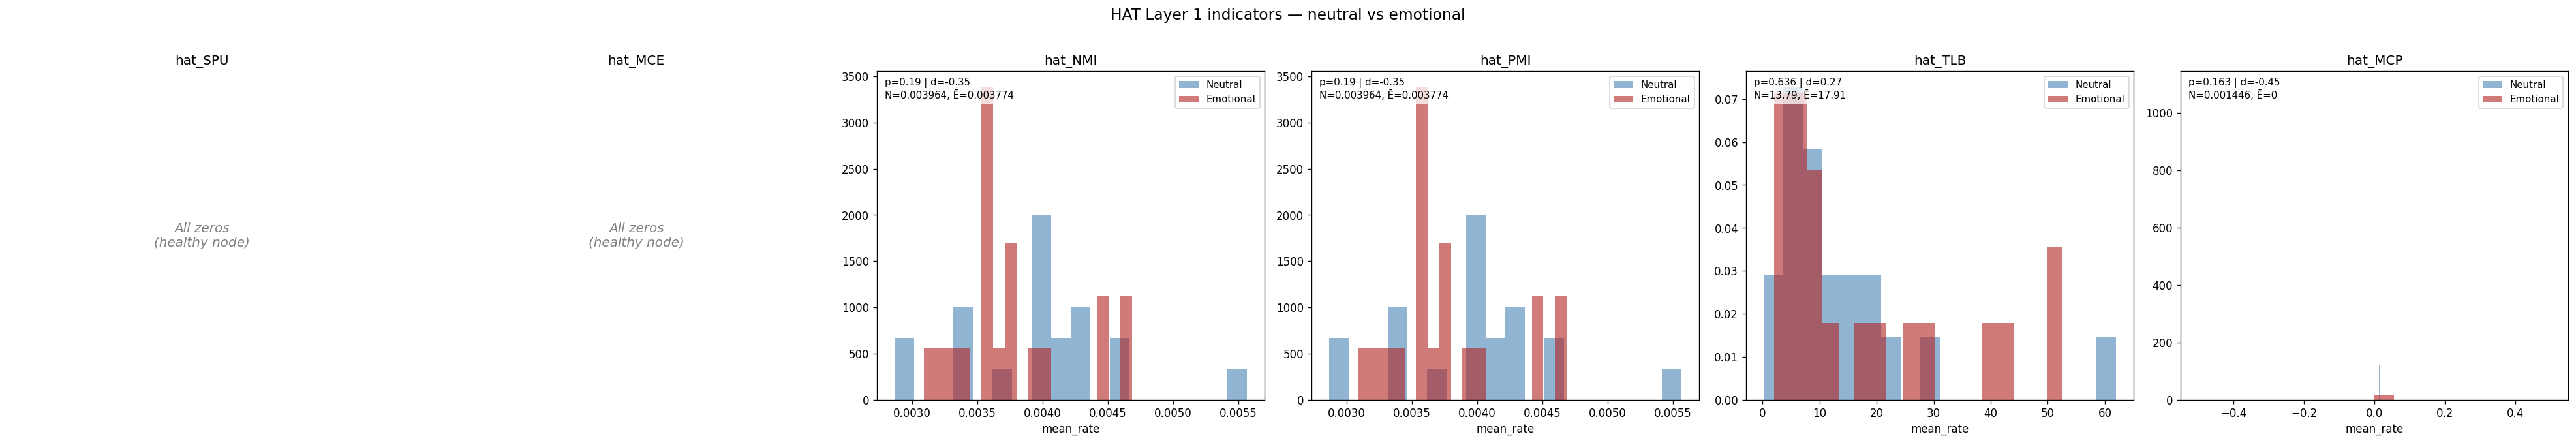


=== Layer 1 vs Layer 2: mean rates ===
Layer Feature                                            Neutral     Emotional        Δ(E-N)     p-value
--------------------------------------------------------------------------------------------------------
  L1   hat_SPU__mean_rate                                  0.0000        0.0000        0.0000      1.0000
  L1   hat_MCE__mean_rate                                  0.0000        0.0000        0.0000      1.0000
  L1   hat_NMI__mean_rate                                  0.0040        0.0038       -0.0002      0.1895
  L1   hat_PMI__mean_rate                                  0.0040        0.0038       -0.0002      0.1895
  L1   hat_TLB__mean_rate                                 13.7864       17.9145        4.1282      0.6359
  L1   hat_MCP__mean_rate                                  0.0014        0.0000       -0.0014      0.1626
  L2   dTLB-load-misses__mean_rate                       688.9497      683.7675       -5.1822      0.9892
  L2   c

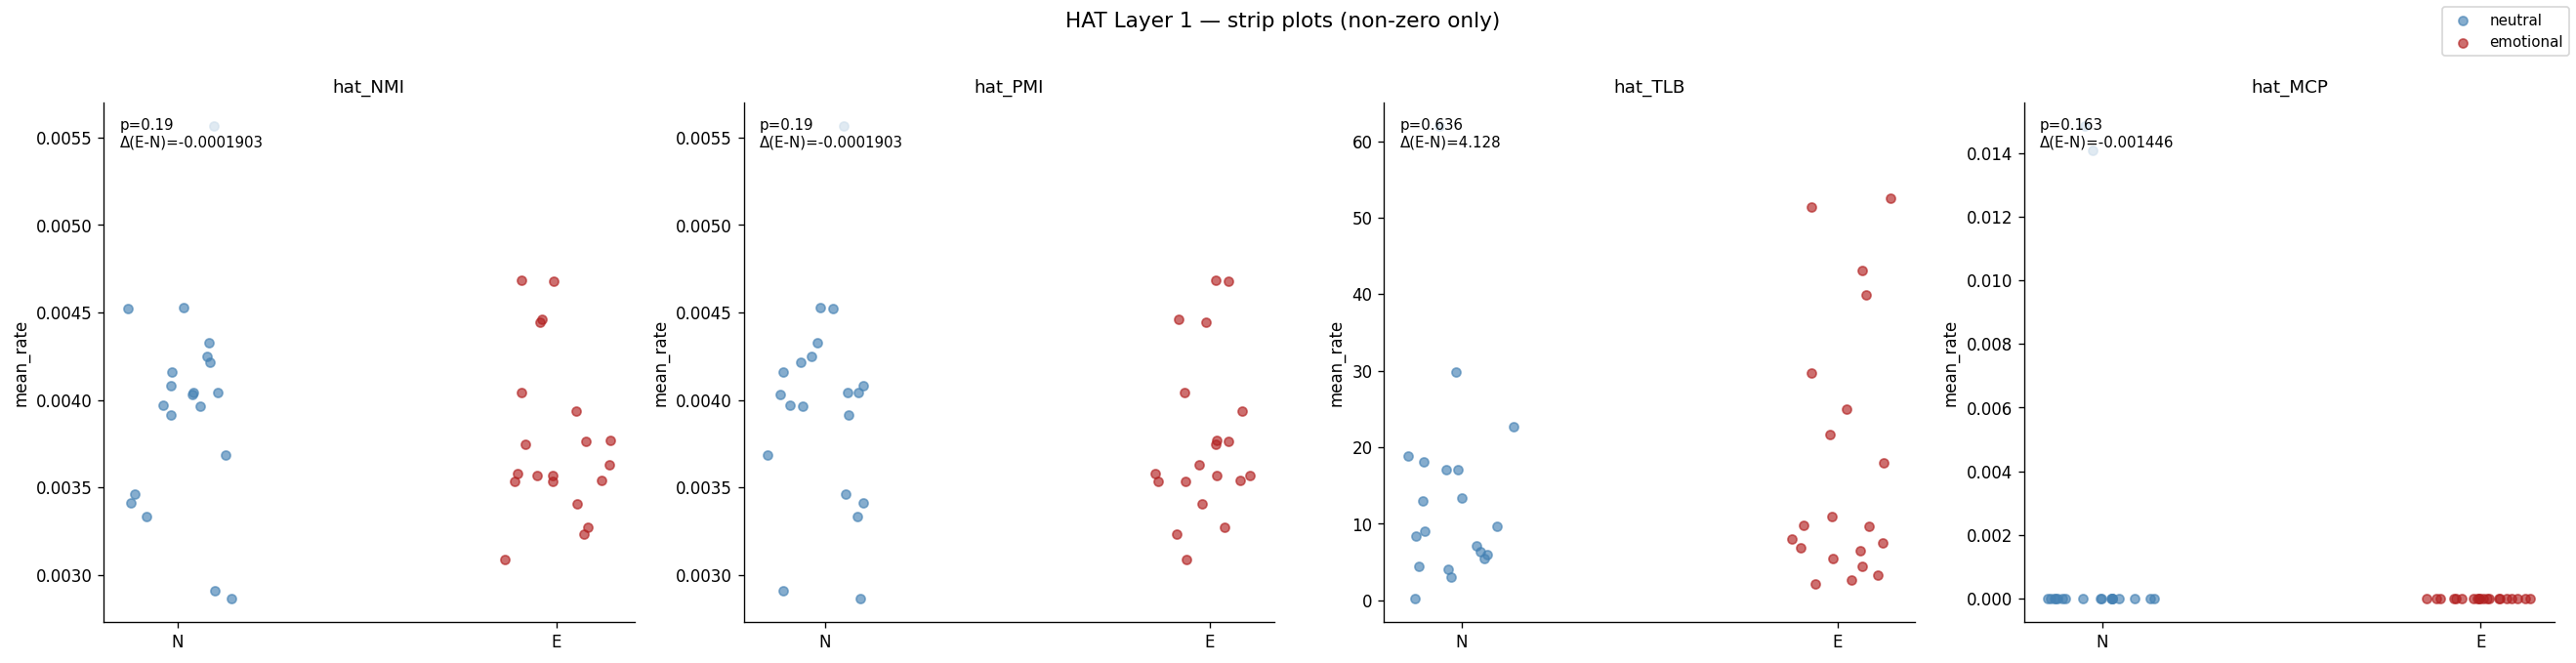

In [38]:
# ── §5b: HAT Layer 1 audit ───────────────────────────────────────────────────
# Genuine hardware anomaly indicators from /proc/interrupts.
# These are the indicators the HAT definition specifically names.

from scipy.stats import mannwhitneyu

HAT_L1_CANDIDATES = [
    'hat_SPU',   # Spurious interrupt
    'hat_MCE',   # Machine Check Exception
    'hat_NMI',   # Non-Maskable Interrupt / perf counter overflow
    'hat_PMI',   # Performance Monitoring Interrupt
    'hat_TLB',   # TLB Shootdown
    'hat_MCP',   # Machine Check Poll
]

# Layer 2 continuous metrics for comparison
HAT_L2_COMPARE = [
    'dTLB-load-misses',
    'cache-misses',
    'cache-references',
    'LLC-load-misses',
    'msr/cpu_thermal_margin/',
    'core_power.throttle',
]

# ── 1. Availability check ─────────────────────────────────────────────────────
print("=== HAT Layer 1 indicator availability ===")
print(f"{'Indicator':<30} {'Present':>8}  {'Column':>30}  {'Signal':>12}")
print("-" * 86)

l1_present = []
for ind in HAT_L1_CANDIDATES:
    col = f"{ind}__mean_rate"
    if col in df_all.columns:
        vals = pd.to_numeric(df_all[col], errors='coerce').dropna()
        all_zero   = (vals.abs() < 1e-9).all()
        near_zero  = (vals.abs() < 1e-9).mean() > 0.95
        tag = 'ALL ZERO' if all_zero else ('~ZERO' if near_zero else 'HAS SIGNAL')
        print(f"  {ind:<28} {'YES':>8}  {col:>30}  {tag:>12}")
        l1_present.append(ind)
    else:
        print(f"  {ind:<28} {'NO':>8}  {'---':>30}  {'---':>12}")

print()
print(f"Present: {l1_present}")

# ── 2. Distribution plots: L1 indicators ─────────────────────────────────────
l1_cols = [f"{ind}__mean_rate" for ind in l1_present]

if l1_cols:
    n_plots = len(l1_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(max(5.5 * n_plots, 15), 5.5))
    if n_plots == 1:
        axes = [axes]

    for ax, col in zip(axes, l1_cols):
        ind_name = col.replace('__mean_rate', '')
        n_vals = pd.to_numeric(df_all.loc[df_all.condition == 'neutral',   col], errors='coerce').dropna()
        e_vals = pd.to_numeric(df_all.loc[df_all.condition == 'emotional', col], errors='coerce').dropna()
        all_zero = (pd.concat([n_vals, e_vals]).abs() < 1e-9).all()

        if all_zero:
            ax.text(0.5, 0.5, 'All zeros\n(healthy node)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=12, color='grey', style='italic')
            ax.set_title(ind_name, fontsize=12)
            ax.set_xticks([]); ax.set_yticks([])
            ax.spines[['top','right','left','bottom']].set_visible(False)
        else:
            ax.hist(n_vals, bins=18, alpha=0.6, color='steelblue', label='Neutral',   density=True)
            ax.hist(e_vals, bins=18, alpha=0.6, color='firebrick', label='Emotional', density=True)
            ax.set_title(ind_name, fontsize=12)
            ax.legend(fontsize=9)

            if len(n_vals) >= 5 and len(e_vals) >= 5:
                _, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
                pooled = np.concatenate([n_vals.values, e_vals.values])
                if pooled.std(ddof=1) > 0:
                    d = (e_vals.mean() - n_vals.mean()) / pooled.std(ddof=1)
                else:
                    d = 0.0
                ax.set_xlabel('mean_rate', fontsize=10)
                ax.text(
                    0.02, 0.98,
                    f"p={p:.3g} | d={d:.2f}\nN̄={n_vals.mean():.4g}, Ē={e_vals.mean():.4g}",
                    transform=ax.transAxes,
                    ha='left', va='top',
                    fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none')
                )
            else:
                ax.set_xlabel('mean_rate (insufficient n for MWU)', fontsize=10)

    plt.suptitle('HAT Layer 1 indicators — neutral vs emotional', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# ── 3. L1 vs L2 mean rate table ───────────────────────────────────────────────
print()
print("=== Layer 1 vs Layer 2: mean rates ===")
print(f"{'Layer':<5} {'Feature':<45} {'Neutral':>12}  {'Emotional':>12}  {'Δ(E-N)':>12}  {'p-value':>10}")
print("-" * 104)

l1_set = {'SPU','MCE','NMI','PMI','TLB','MCP'}
compare_cols = (
    [f"{ind}__mean_rate" for ind in l1_present] +
    [f"{ind}__mean_rate" for ind in HAT_L2_COMPARE if f"{ind}__mean_rate" in df_all.columns]
)

for col in compare_cols:
    if col not in df_all.columns:
        continue
    n_vals = pd.to_numeric(df_all.loc[df_all.condition == 'neutral',   col], errors='coerce').dropna()
    e_vals = pd.to_numeric(df_all.loc[df_all.condition == 'emotional', col], errors='coerce').dropna()
    if len(n_vals) < 3 or len(e_vals) < 3:
        continue
    _, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
    ind = col.replace('__mean_rate','').replace('hat_','')
    layer = 'L1' if ind in l1_set else 'L2'
    delta = e_vals.mean() - n_vals.mean()
    print(f"  {layer:<4} {col:<45} {n_vals.mean():>12.4f}  {e_vals.mean():>12.4f}  {delta:>12.4f}  {p:>10.4f}")

# ── 4. Strip plots: non-zero L1 indicators only ───────────────────────────────
strip_cols = [
    c for c in l1_cols
    if not (pd.to_numeric(df_all[c], errors='coerce').abs() < 1e-9).all()
]

if strip_cols:
    n_s = len(strip_cols)
    fig, axes = plt.subplots(1, n_s, figsize=(5.5 * n_s, 5.5))
    if n_s == 1:
        axes = [axes]
    rng = np.random.default_rng(42)
    for ax, col in zip(axes, strip_cols):
        n_vals = pd.to_numeric(df_all.loc[df_all.condition == 'neutral', col], errors='coerce').dropna().values
        e_vals = pd.to_numeric(df_all.loc[df_all.condition == 'emotional', col], errors='coerce').dropna().values

        for cond, vals, color, x_pos in [
            ('neutral', n_vals, 'steelblue', 0),
            ('emotional', e_vals, 'firebrick', 1)
        ]:
            jitter = rng.uniform(-0.15, 0.15, len(vals))
            ax.scatter(np.full(len(vals), x_pos) + jitter, vals,
                       color=color, alpha=0.65, s=30, label=cond)

        if len(n_vals) >= 5 and len(e_vals) >= 5:
            _, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
            ax.text(
                0.03, 0.97,
                f"p={p:.3g}\nΔ(E-N)={(e_vals.mean()-n_vals.mean()):.4g}",
                transform=ax.transAxes,
                ha='left', va='top', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none')
            )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['N', 'E'])
        ax.set_title(col.replace('__mean_rate', ''), fontsize=11)
        ax.set_ylabel('mean_rate', fontsize=10)
        ax.spines[['top','right']].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9)
    plt.suptitle('HAT Layer 1 — strip plots (non-zero only)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print()
    print("=" * 60)
    print("All Layer 1 indicators are zero across all trials.")
    print("Healthy node confirmed: no spurious, MCE, NMI/PMI, or MCP events.")
    print("Signal discrimination lives entirely in Layer 2 (continuous metrics).")
    print("=" * 60)


In [ ]:
# ── Per-run last analysis (Section 5b) ─────────────────────────────────────────
# Uses dfs_by_run created in Section 3 and plots the same final HAT-L1 analysis
# separately for A/B/D/E/F.

from scipy.stats import mannwhitneyu

if 'dfs_by_run' not in globals() or not dfs_by_run:
    raise RuntimeError('Run Section 3 first to create dfs_by_run.')

HAT_L1_CANDIDATES = [
    'hat_SPU', 'hat_MCE', 'hat_NMI', 'hat_PMI', 'hat_TLB', 'hat_MCP'
]


def _run_last_analysis_for_df(df_in: pd.DataFrame, run_label: str):
    print('\n' + '=' * 90)
    print(f'RUN {run_label} — Section 5b HAT Layer 1 audit')
    print('=' * 90)

    l1_present = []
    for ind in HAT_L1_CANDIDATES:
        col = f"{ind}__mean_rate"
        if col in df_in.columns:
            l1_present.append(ind)

    if not l1_present:
        print('No HAT Layer 1 mean_rate columns found for this run.')
        return

    l1_cols = [f"{ind}__mean_rate" for ind in l1_present]

    # Distribution plots
    n_plots = len(l1_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(max(5.5 * n_plots, 15), 5.5))
    if n_plots == 1:
        axes = [axes]

    for ax, col in zip(axes, l1_cols):
        ind_name = col.replace('__mean_rate', '')
        n_vals = pd.to_numeric(df_in.loc[df_in.condition == 'neutral', col], errors='coerce').dropna()
        e_vals = pd.to_numeric(df_in.loc[df_in.condition == 'emotional', col], errors='coerce').dropna()
        all_zero = (pd.concat([n_vals, e_vals]).abs() < 1e-9).all()

        if all_zero:
            ax.text(0.5, 0.5, 'All zeros\n(healthy node)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=12, color='grey', style='italic')
            ax.set_title(ind_name, fontsize=12)
            ax.set_xticks([]); ax.set_yticks([])
            ax.spines[['top','right','left','bottom']].set_visible(False)
        else:
            ax.hist(n_vals, bins=18, alpha=0.6, color='steelblue', label='Neutral', density=True)
            ax.hist(e_vals, bins=18, alpha=0.6, color='firebrick', label='Emotional', density=True)
            ax.set_title(ind_name, fontsize=12)
            ax.legend(fontsize=9)

            if len(n_vals) >= 5 and len(e_vals) >= 5:
                _, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
                pooled = np.concatenate([n_vals.values, e_vals.values])
                d = ((e_vals.mean() - n_vals.mean()) / pooled.std(ddof=1)) if pooled.std(ddof=1) > 0 else 0.0
                ax.text(
                    0.02, 0.98,
                    f"p={p:.3g} | d={d:.2f}\nN̄={n_vals.mean():.4g}, Ē={e_vals.mean():.4g}",
                    transform=ax.transAxes,
                    ha='left', va='top', fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none')
                )
            ax.set_xlabel('mean_rate', fontsize=10)

    plt.suptitle(f'HAT Layer 1 indicators — neutral vs emotional (Run {run_label})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


for run in RUNS:
    _run_last_analysis_for_df(dfs_by_run[run], run)
